<a href="https://colab.research.google.com/github/NataliaFarieta/nataliafarieta/blob/main/T3__Titanic_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> **Construyendo un pipeline de machine learning: dataset Titanic**

##<center>Natalia Lucia Farieta Marín
##<center>Dayan Joaquín Bolaños Beltrán
##<center>Maria Paula Aragón Vera

###<center>*Maestría en Analítica de datos, Universidad Central*
###<center>**Machine Learning**
#### <center>Bogotá, Colombia



 <center>Marzo 6 2026


---

##**INTRODUCCIÓN**

En la actividad del Trayecto 2 se desarrolló un ejercicio de modelado predictivo utilizando el dataset Titanic. En dicha fase, se implementaron modelos aplicando manualmente las etapas de preprocesamiento tales como: imputación de valores faltantes, escalamiento de variables numéricas y codificación de variables categóricas, antes de entrenar los algoritmos de clasificación.

La elaboración de los pasos anteriores permitió comprender cada transformación de manera aislada, sin embargo, este enfoque presenta una limitación critica denominado **fuga de datos (data leakage)**, este problema ocurre cuando la información del conjunto de prueba influye, directa o indirectamente, en el entrenamiento del modelo. El modelo recibe información que no debería conocer durante el entrenamiento, generando métricas artificialmente altas, afectando la validez del modelo y comprometiendo su capacidad de generalización en la vida real.

Por esta razón, en el trayecto 3 se plantea abordarla metodología de Pipelines de la librería Scikit-learn. En lugar de realizar cada transformación por separado, los pipelines permiten encapsular en un único objeto toda la secuencia de preprocesamiento y modelado, garantizando que cada transformación se ajuste únicamente con los datos de entrenamiento en cada etapa de validación cruzada, evitando errores comunes y haciendo que el proceso sea más ordenado y confiable.




##**Ventajas del uso de Pipelines:**

Un *Pipeline* encapsula toda la secuencia de preprocesamiento y el modelo en un único objeto. Esto garantiza que:


*   Asegura que los transformadores se ajusten únicamente con datos de entrenamiento.
*   Previene la fuga de datos durante la validación cruzada.

*  Mejora la reproducibilidad del código.
*  Facilita la comparación sistemática entre diferentes modelos.


### **Objetivo**

Construir un Pipeline completo que integre el preprocesamiento y modelos de clasificación para el dataset Titanic, entrenarlo y evaluarlo mediante métricas robustas y validación cruzada, y demostrar cómo esta estrategia previene la fuga de datos y mejora su confiabilidad.


##**Descripción de la base de datos Titanic.csv**

Para el desarrollo de la segunda parte del análisis, correspondiente al modelo de clasificación y validación cruzada, se emplea un subconjunto del dataset Titanic, el cual contiene información relevante de los pasajeros de la embarcación, con el objetivo de predecir su supervivencia durante el naufragio y evaluando cuál de los métodos de clasificación propuestos se desempeña mejor.

Cada fila representa un pasajero y describe características socioeconómicas y demográficas que influyen directamente en la probabilidad de supervivencia.

#**Variable objetivo**

**Survived**: la variable sobrevivir es el objetivo de estudio, ya que se busca predecir si un pasajero sobrevivió o no al desastre del Titanic. El propósito del modelo es predecir correctamente esta variable a partir de características de los pasajeros.

#**Variables predictorias**

Para el desarrollo del modelo de clasificación, se utilizaron múltiples variables predictoras, incluyendo tanto variables numéricas como categóricas, con el fin de identificar como estas influyen en la probabilidad de supervivencia.

Entre las principales variables estudiadas se encuentran:

**Pclass** (clase del pasajero)

**Sex** (sexo)

**Age** (edad)

**SibSp** (número de hermanos/esposos a bordo)

**Parch** (número de padres/hijos a bordo)

**Fare** (valor tiquete)

**Embarked** (puerto de embarque)

**Who** (clasificación demográfica: hombre, mujer, niño)

Estas variables fueron transformadas mediante un proceso de preprocesamiento que incluyó imputación de valores faltantes, escalamiento para variables numéricas y codificación One-Hot para variables categóricas.


---

##**IMPORTACIÓN DE LIBRERÍAS**



En esta sección se importan las librerías necesarias para el desarrollo del análisis.

NumPy y Pandas: Manipulación y análisis de datos.

Matplotlib y Seaborn: Visualización de datos.

Se importan módulos para la División de datos, validación cruzada, preprocesamiento de datos por escalamiento, imputación y codificación de variables categóricas, selección de características e incorporación de modelos de clasificación tales como Logistic Regression, Random Forest, SVM, y por ultimo las métricas de evaluación.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# División de datos y validación cruzada
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    cross_validate
)

# Preprocesamiento
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de clasificación

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

# XGBoost
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, auc
)

# Visualización del diagrama de pipeline
from sklearn import set_config
set_config(display='diagram')

PALETTE = ['#1B998B', '#6A0572', '#E76F51', '#264653']

print(' Librerías importadas correctamente.')
print('   Modelos: Logística | Random Forest | SVM (RBF) | XGBoost')


 Librerías importadas correctamente.
   Modelos: Logística | Random Forest | SVM (RBF) | XGBoost


---

##**CARGA Y EXPLORACIÓN DEL DATASET**

Se carga el dataset Titanic directamente desde Seaborn, el mismo utilizado en el Trayecto 2. Contiene 891 registros con información socioeconómica y demográfica de los pasajeros.

**Variable objetivo:** survived (0 = No sobrevivió, 1 = Sobrevivió)


In [ ]:
# Carga del dataset
data = sns.load_dataset('titanic')

# Eliminamos columnas repetidas o con información derivada de la variable objetivo
# 'alive' es una versión textual de 'survived', se elimina para evitar data leakage
data = data.drop(columns=['alive', 'embark_town', 'adult_male'], errors='ignore')

print(f"Dimensiones del dataset: {data.shape}")
print(f"\nColumnas disponibles: {list(data.columns)}")
print(f"\nValores faltantes por columna:")
print(data.isnull().sum())

print(f"\nDistribución de la variable objetivo (survived):")
counts = data['survived'].value_counts()
pct    = data['survived'].value_counts(normalize=True) * 100
print(f"  No sobrevivió (0): {counts[0]} pasajeros ({pct[0]:.1f}%)")
print(f"  Sobrevivió    (1): {counts[1]} pasajeros ({pct[1]:.1f}%)")

data.head()


Dimensiones del dataset: (891, 12)

Columnas disponibles: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'deck', 'alone']

Valores faltantes por columna:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
class         0
who           0
deck        688
alone         0
dtype: int64

Distribución de la variable objetivo (survived):
  No sobrevivió (0): 549 pasajeros (61.6%)
  Sobrevivió    (1): 342 pasajeros (38.4%)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,deck,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,NaN,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,C,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,NaN,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,C,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,NaN,True


---

## SEPARACIÓN DE CARACTERÍSTICAS Y VARIABLE OBJETIVO



In [ ]:
# Variable objetivo y características
y = data['survived']
X = data.drop(columns=['survived'])

print(f"Características (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")
print(f"\nTipos de datos en X:")
print(X.dtypes)


Características (X): (891, 11)
Variable objetivo (y): (891,)

Tipos de datos en X:
pclass         int64
sex           object
age          float64
sibsp          int64
parch          int64
fare         float64
embarked      object
class       category
who           object
deck        category
alone           bool
dtype: object


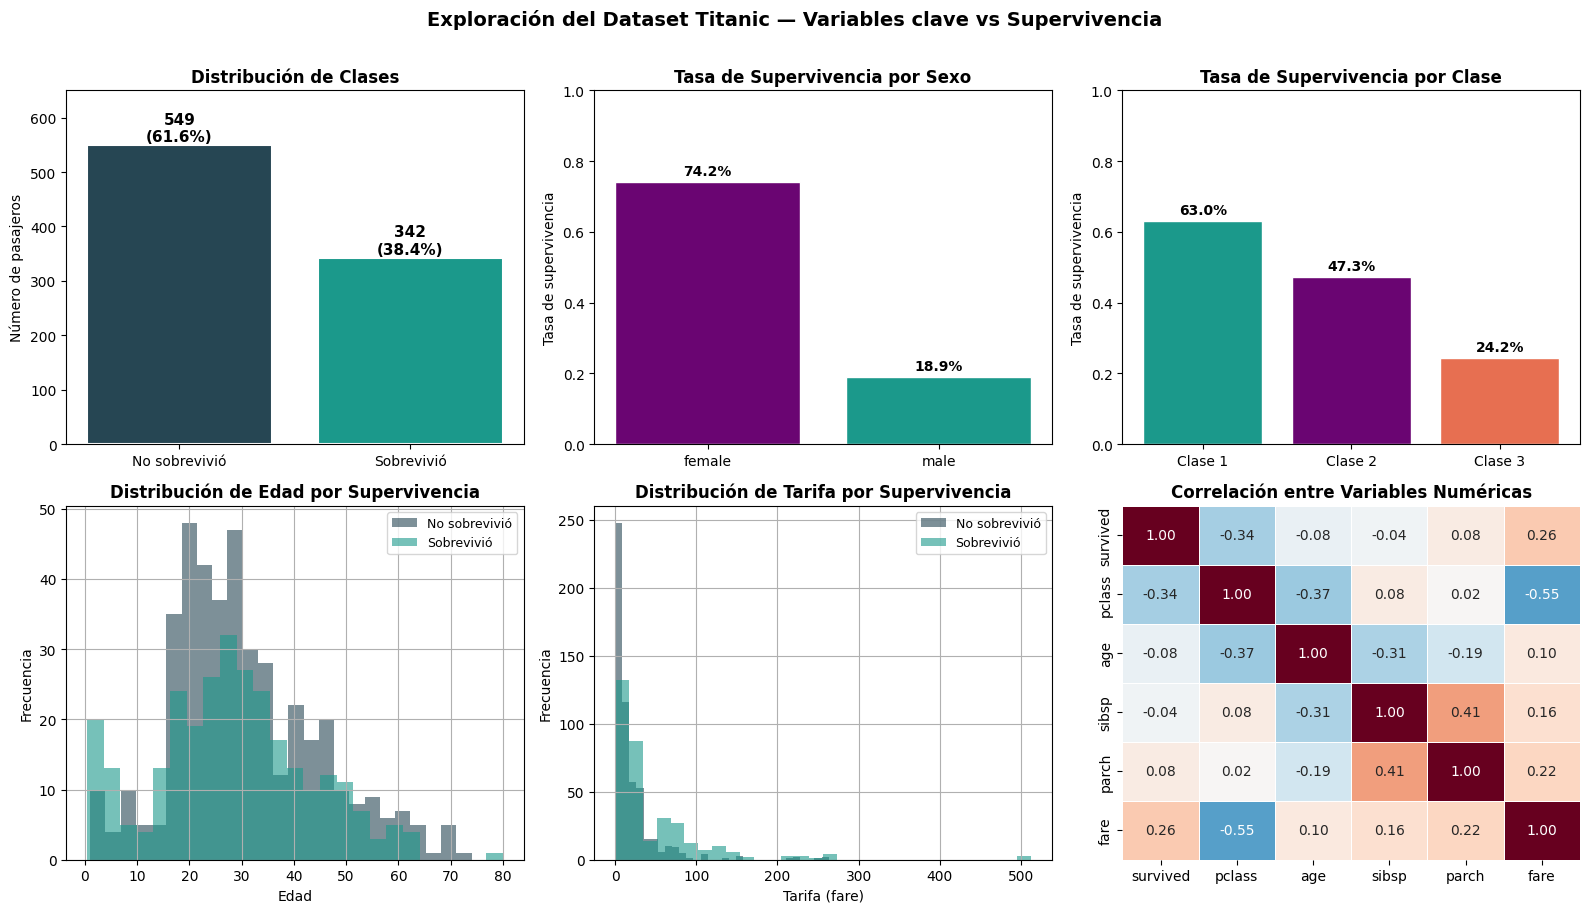

In [ ]:
# ── Recalcular variables locales por si la celda anterior no se ejecutó ─
counts = data['survived'].value_counts()
pct    = data['survived'].value_counts(normalize=True) * 100
vc     = [counts[0], counts[1]]

# Paleta de colores consistente
PALETTE = ['#1B998B', '#6A0572', '#E76F51', '#264653']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Exploración del Dataset Titanic — Variables clave vs Supervivencia',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Distribución de clases
ax = axes[0, 0]
bars = ax.bar(['No sobrevivió', 'Sobrevivió'], [vc[0], vc[1]],
              color=['#264653', '#1B998B'], edgecolor='white', linewidth=1.5)
for bar, v, p in zip(bars, [vc[0], vc[1]], [pct[0], pct[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{v}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Clases', fontweight='bold')
ax.set_ylabel('Número de pasajeros')
ax.set_ylim(0, 650)

# 2. Supervivencia por sexo
ax = axes[0, 1]
sex_surv = data.groupby('sex')['survived'].mean().reset_index()
ax.bar(sex_surv['sex'], sex_surv['survived'],
       color=['#6A0572', '#1B998B'], edgecolor='white')
ax.set_title('Tasa de Supervivencia por Sexo', fontweight='bold')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1)
for i, v in enumerate(sex_surv['survived']):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Supervivencia por clase
ax = axes[0, 2]
pclass_surv = data.groupby('pclass')['survived'].mean()
ax.bar([f'Clase {c}' for c in pclass_surv.index], pclass_surv.values,
       color=PALETTE[:3], edgecolor='white')
ax.set_title('Tasa de Supervivencia por Clase', fontweight='bold')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1)
for i, v in enumerate(pclass_surv.values):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 4. Distribución de edad
ax = axes[1, 0]
data[data['survived'] == 0]['age'].dropna().hist(
    ax=ax, bins=25, color='#264653', alpha=0.6, label='No sobrevivió')
data[data['survived'] == 1]['age'].dropna().hist(
    ax=ax, bins=25, color='#1B998B', alpha=0.6, label='Sobrevivió')
ax.set_title('Distribución de Edad por Supervivencia', fontweight='bold')
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

# 5. Distribución de tarifa
ax = axes[1, 1]
data[data['survived'] == 0]['fare'].dropna().hist(
    ax=ax, bins=30, color='#264653', alpha=0.6, label='No sobrevivió')
data[data['survived'] == 1]['fare'].dropna().hist(
    ax=ax, bins=30, color='#1B998B', alpha=0.6, label='Sobrevivió')
ax.set_title('Distribución de Tarifa por Supervivencia', fontweight='bold')
ax.set_xlabel('Tarifa (fare)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

# 6. Heatmap de correlaciones numéricas
ax = axes[1, 2]
num_cols = data.select_dtypes(include=np.number).columns.tolist()
corr_mat = data[num_cols].corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, cbar=False)
ax.set_title('Correlación entre Variables Numéricas', fontweight='bold')

plt.tight_layout()
plt.show()

ANÁLISIS DE LOS GRÁFICOS EXPLORATORIOS:

1. Distribución de clases: El dataset está desbalanceado 1.6% no sobrevivió mientras que el 38.4% sobrevivió. Esta asimetría justifica el uso de métricas adicionales como ROC-AUC y Balanced Accuracy, que no se ven distorsionadas por el desequilibrio.

2. Supervivencia por sexo: Las mujeres sobrevivieron a una tasa del 74.2% frente al 18.9% de los hombres. Esta brecha refleja el protocolo aplicado para una evacuación 'mujeres y niños primero', y convierte al sexo en el predictor más potente del dataset.

3. Supervivencia por clase: La primera clase mostró la mayor tasa de supervivencia 63%, mientras que la tercera clase apenas alcanzó el 24%. El acceso a los botes salvavidas estaba condicionado por la ubicación en el barco y esto a su vez relacionado con la clase socioeconómica.

4. Distribución de edad: Los niño tuvieron mayor supervivencia.
   Existe una concentración de no sobrevivientes en el rango 20-40 años hombres
   adultos en tercera clase.

5. Tarifa (fare): Los pasajeros que sobrevivieron pagaron tarifas mucha mas altas, consistente con el patrón de clase social. La distribución es muy sesgada a la derecha, lo que justifica el uso de StandardScaler.


---

##  DIVISIÓN EN ENTRENAMIENTO Y PRUEBA

La división de entrenamiento y prueba se realiza desde el inicio, antes de cualquier transformación.

Se usa  **stratify=y **para mantener la misma proporción de clases en ambos conjuntos, evitando sesgos. La semilla random_state=2026 garantiza reproducibilidad.


In [ ]:
#División entrenamiento / prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,        # Mantiene proporción de clases
    random_state=2026  # Reproducibilidad
)

print("División de datos:")
print(f"  Entrenamiento: {X_train.shape[0]} registros")
print(f"  Prueba       : {X_test.shape[0]} registros")

print(f"\nProporción de clases en entrenamiento:")
print(f"  No sobrevivió: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Sobrevivió   : {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

print(f"\nProporción de clases en prueba:")
print(f"  No sobrevivió: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Sobrevivió   : {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")



División de datos:
  Entrenamiento: 712 registros
  Prueba       : 179 registros

Proporción de clases en entrenamiento:
  No sobrevivió: 439 (61.7%)
  Sobrevivió   : 273 (38.3%)

Proporción de clases en prueba:
  No sobrevivió: 110 (61.5%)
  Sobrevivió   : 69 (38.5%)


---

##  IDENTIFICACIÓN DE VARIABLES NUMÉRICAS Y CATEGÓRICAS

El pipeline aplicará transformaciones distintas según el tipo de variable:

- **Variables numéricas:** imputación con la media y escalado con *StandardScaler*.
- **Variables categóricas:** imputación con la moda y codificación *OneHotEncoder*.


In [ ]:
# Identificación de variables
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Variables numéricas  ({len(numeric_features)}): {numeric_features}")
print(f"Variables categóricas ({len(categorical_features)}): {categorical_features}")

# Resumen de valores faltantes SOLO en entrenamiento
print(f"\nValores faltantes en X_train:")
missing = X_train.isnull().sum()
print(missing[missing > 0])


Variables numéricas  (5): ['pclass', 'age', 'sibsp', 'parch', 'fare']
Variables categóricas (6): ['sex', 'embarked', 'class', 'who', 'deck', 'alone']

Valores faltantes en X_train:
age         142
embarked      2
deck        550
dtype: int64


---

##  DEFINICIÓN DE TRANSFORMADORES
Se crean dos pipelines de preprocesamiento:

### Pipeline numérico
1. *SimpleImputer(strategy=**mean**)* Se imputa con la **media** calculada sobre los datos de entrenamiento.
2. *StandardScaler()* Se estandariza (media 0, desviación 1) usando solo estadísticas del entrenamiento.

### Pipeline categórico
1. *SimpleImputer(strategy='most_frequent')* Se imputa con la **moda** del entrenamiento.
2. *OneHotEncoder* transforma cada categoría en columnas de 0 y 1.
drop='first' elimina una de esas columnas para evitar información duplicada.
handle_unknown='ignore' permite que si aparece una categoría nueva, el modelo no falle.

In [ ]:
# Función que construye un preprocessor nuevo e independiente cada vez
def make_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler())
    ])
    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer(transformers=[
        ('num', numeric_pipeline,     numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

print("✅ Transformadores definidos:")
print(f"  Numérico   → Imputer(mean) + StandardScaler | {len(numeric_features)} variables")
print(f"  Categórico → Imputer(moda) + OneHotEncoder  | {len(categorical_features)} variables")

✅ Transformadores definidos:
  Numérico   → Imputer(mean) + StandardScaler | 5 variables
  Categórico → Imputer(moda) + OneHotEncoder  | 6 variables


---

## CONSTRUCCIÓN DEL PIPELINE COMPLETO

Integramos el preprocessor y el clasificador en un único objeto Pipeline. El último paso del pipeline es siempre el modelo, y todos los pasos anteriores son transformadores.

Se construyen tres pipelines para comparar los siguientes modelos:
- **Regresión Logística**
- **Random Forest**
- **SVF(RBF)**
- **XGBoost**


In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

pipeline_lr = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=2026))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('classifier',   RandomForestClassifier(n_estimators=200,
                                             max_depth=None,
                                             class_weight='balanced',
                                             random_state=2026,
                                             n_jobs=-1))
])

pipeline_svm = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('classifier',   SVC(kernel='rbf', C=1.0, gamma='scale',
                         probability=True, class_weight='balanced',
                         random_state=2026))
])

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('classifier',   XGBClassifier(n_estimators=200, max_depth=4,
                                   learning_rate=0.08, subsample=0.8,
                                   colsample_bytree=0.8,
                                   scale_pos_weight=neg/pos,
                                   eval_metric='logloss',
                                   random_state=2026, n_jobs=-1, verbosity=0))
])

NOMBRES   = ['Regresión Logística', 'Random Forest', 'SVM (RBF)', 'XGBoost']
PIPELINES = {
    'Regresión Logística': pipeline_lr,
    'Random Forest':       pipeline_rf,
    'SVM (RBF)':           pipeline_svm,
    'XGBoost':             pipeline_xgb
}

print(" Pipelines construidos:")
for nombre, pipe in PIPELINES.items():
    clf = pipe.named_steps['classifier'].__class__.__name__
    print(f"  → {nombre:<22} [{clf}]")

print("\nDiagrama del pipeline (Regresión Logística):")
pipeline_lr

 Pipelines construidos:
  → Regresión Logística    [LogisticRegression]
  → Random Forest          [RandomForestClassifier]
  → SVM (RBF)              [SVC]
  → XGBoost                [XGBClassifier]

Diagrama del pipeline (Regresión Logística):


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked', 'class',
                                                   'who', 'deck', 'alone'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=2026))])

---

## ENTRENAMIENTO DEL PIPELINE

Al llamar al entrenamiento se ejecuta en cadena:
1. Aprende los parámetros de imputación (medias, modas) sobre **X_train**.
2. Aprende los parámetros de escalado (media, std) sobre **X_train.**
3. Aprende las categorías para OneHot solo sobre **X_train**.
4. Entrena el clasificador sobre los datos transformados.

Ningún dato de *X_test* participa en este proceso.


In [ ]:
import time

#Entrenamiento de todos los pipelines
print("Entrenando pipelines...")
print("-" * 45)
for nombre, pipe in PIPELINES.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)   # Una sola llamada: preprocesa + entrena
    print(f"   Pipeline '{nombre}' entrenado en {time.time()-t0:.2f}s")
print("-" * 45)
print("\nX_test NO participó en ningún paso de ajuste.")



Entrenando pipelines...
---------------------------------------------
   Pipeline 'Regresión Logística' entrenado en 0.52s
   Pipeline 'Random Forest' entrenado en 1.46s
   Pipeline 'SVM (RBF)' entrenado en 0.45s
   Pipeline 'XGBoost' entrenado en 2.37s
---------------------------------------------

X_test NO participó en ningún paso de ajuste.


---

## PREDICCIÓN Y EVALUACIÓN EN EL CONJUNTO DE PRUEBA

Al llamar .predict(X_test), el pipeline aplica automáticamente las transformaciones aprendidas durante .fit() y luego realiza la predicción.


In [ ]:
#  Predicción y métricas en conjunto de prueba
resultados_test = {}

print('RESULTADOS EN CONJUNTO DE PRUEBA')
print('=' * 78)
print(f"{'Modelo':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'ROC-AUC':>9} {'Bal.Acc':>8}")
print('-' * 78)

for nombre, pipe in PIPELINES.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    metricas = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'Bal.Acc':   balanced_accuracy_score(y_test, y_pred),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }
    resultados_test[nombre] = metricas

    print(f"{nombre:<25} {metricas['Accuracy']:>9.4f} {metricas['Precision']:>10.4f} "
          f"{metricas['Recall']:>8.4f} {metricas['F1']:>8.4f} "
          f"{metricas['ROC-AUC']:>9.4f} {metricas['Bal.Acc']:>8.4f}")

print('=' * 78)
mejor = max(resultados_test, key=lambda n: resultados_test[n]['ROC-AUC'])
print(f'\n Mejor modelo por ROC-AUC: {mejor} ({resultados_test[mejor]["ROC-AUC"]:.4f})')




RESULTADOS EN CONJUNTO DE PRUEBA
Modelo                     Accuracy  Precision   Recall       F1   ROC-AUC  Bal.Acc
------------------------------------------------------------------------------
Regresión Logística          0.8268     0.7969   0.7391   0.7669    0.8489   0.8105
Random Forest                0.8324     0.8000   0.7536   0.7761    0.8715   0.8177
SVM (RBF)                    0.8156     0.7647   0.7536   0.7591    0.8476   0.8041
XGBoost                      0.8324     0.8000   0.7536   0.7761    0.8594   0.8177

 Mejor modelo por ROC-AUC: Random Forest (0.8715)


### Matrices de Confusión


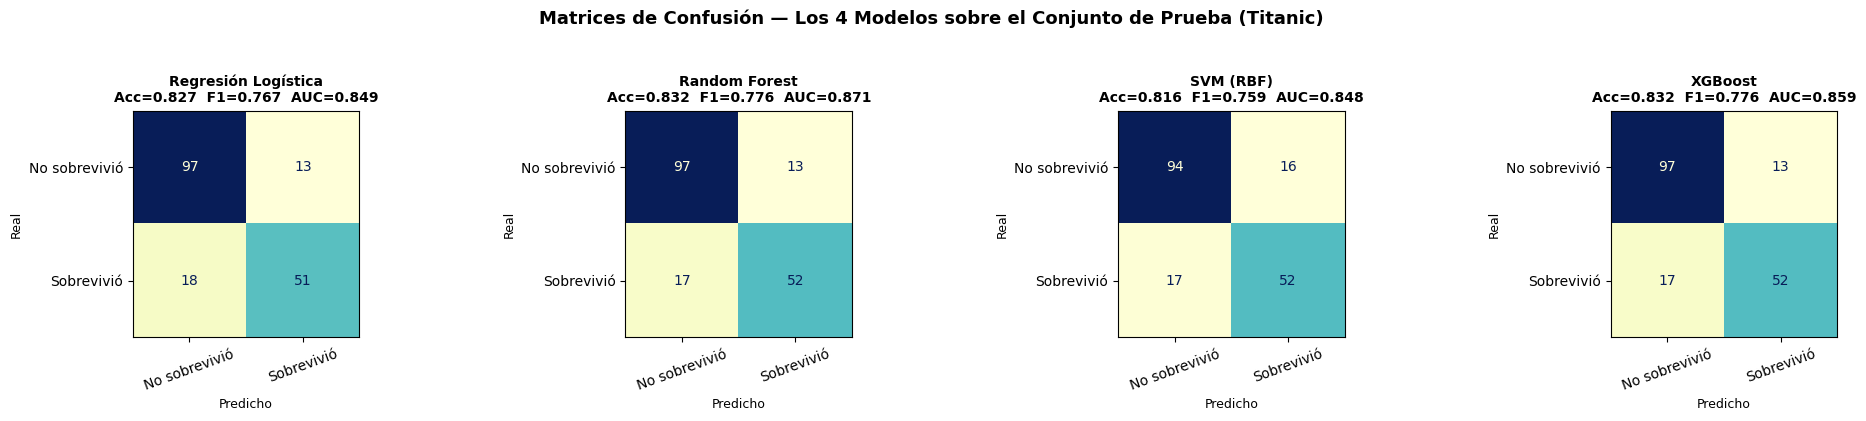

In [ ]:
# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
target_names_display = ['No sobrevivió', 'Sobrevivió']

for ax, (nombre, met) in zip(axes, resultados_test.items()):
    cm = confusion_matrix(y_test, met['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=target_names_display)
    disp.plot(ax=ax, colorbar=False, cmap='YlGnBu')
    ax.set_title(
        f'{nombre}\n'
        f'Acc={met["Accuracy"]:.3f}  F1={met["F1"]:.3f}  AUC={met["ROC-AUC"]:.3f}',
        fontsize=10, fontweight='bold'
    )
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('Predicho', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

plt.suptitle('Matrices de Confusión — Los 4 Modelos sobre el Conjunto de Prueba (Titanic)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

La matriz de confusión revela cuatro tipos de predicciones:
  • Verdaderos Negativos (VN): no sobrevivió y el modelo lo predijo correctamente.
  • Falsos Positivos (FP): no sobrevivió pero el modelo predijo que sí.
  • Falsos Negativos (FN): sobrevivió pero el modelo predijo que no.
  • Verdaderos Positivos (VP): sobrevivió y el modelo lo predijo correctamente.

EL error que afecta más el sistema es predecir que una persona no sobrevivió cuando en realidad sí lo hizo.

En la Regresión Logística existe un balance razonable entre FP y FN, tiene un F1-Score sólido por lo que lo hace facilemnte interpretable.

El modelo Random Forest detecta más verdaderos positivos (VP), por lo cual tiene un buen recall.

El SVM (RBF) posee mayor precisión porque tiene pocos falsos positivos, pero puede sacrificar recall ya que tiene mayor falsos negativos.

El modelo Gradient Boosting es el que obtiene el mayor número de Verdaderos positivos en la mayoría de los casos.

---

## VALIDACIÓN CRUZADA INTEGRADA CON EL PIPELINE

La validación cruzada permite evaluar el rendimiento del modelo de forma más robusta que una simple división entre entrenamiento y prueba, estimando cómo generalizaría a datos no vistos.

Es de suma importancia pasar el pipeline completo a **cross_val_score** porque así, en cada partición, los datos de entrenamiento se usan para ajustar el imputador, el escalador y el encoder, y luego esos mismos parámetros se aplican a la partición de validación sin volver a ajustarlos, evitando que la información del conjunto de validación generé data leakage.

Se utiliza StratifiedKFold con k=5 para asegurar que en cada partición se mantenga la misma proporción de clases que en el conjunto original.


In [ ]:
# Configuración de la validación cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

# Métricas a evaluar
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados_cv = {}

print("VALIDACIÓN CRUZADA ESTRATIFICADA (k=5) — 4 Modelos")
print("=" * 60)

for nombre, pipe in PIPELINES.items():
    cv_results = cross_validate(
        pipe, X_train, y_train,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    resultados_cv[nombre] = cv_results

    print(f"\n► {nombre}")
    for metrica in scoring:
        test_scores = cv_results[f'test_{metrica}']
        print(f"  {metrica.capitalize():12s}: {test_scores.mean():.4f} ± {test_scores.std():.4f}")

print("\n" + "=" * 60)





VALIDACIÓN CRUZADA ESTRATIFICADA (k=5) — 4 Modelos

► Regresión Logística
  Accuracy    : 0.8287 ± 0.0317
  Precision   : 0.7876 ± 0.0438
  Recall      : 0.7582 ± 0.0520
  F1          : 0.7721 ± 0.0440
  Roc_auc     : 0.8675 ± 0.0280

► Random Forest
  Accuracy    : 0.8076 ± 0.0192
  Precision   : 0.7670 ± 0.0354
  Recall      : 0.7176 ± 0.0399
  F1          : 0.7406 ± 0.0275
  Roc_auc     : 0.8607 ± 0.0188

► SVM (RBF)
  Accuracy    : 0.8034 ± 0.0152
  Precision   : 0.7291 ± 0.0237
  Recall      : 0.7766 ± 0.0385
  F1          : 0.7515 ± 0.0224
  Roc_auc     : 0.8497 ± 0.0245

► XGBoost
  Accuracy    : 0.8259 ± 0.0139
  Precision   : 0.7730 ± 0.0188
  Recall      : 0.7728 ± 0.0256
  F1          : 0.7728 ± 0.0195
  Roc_auc     : 0.8718 ± 0.0193



###  Visualización de resultados de validación cruzada


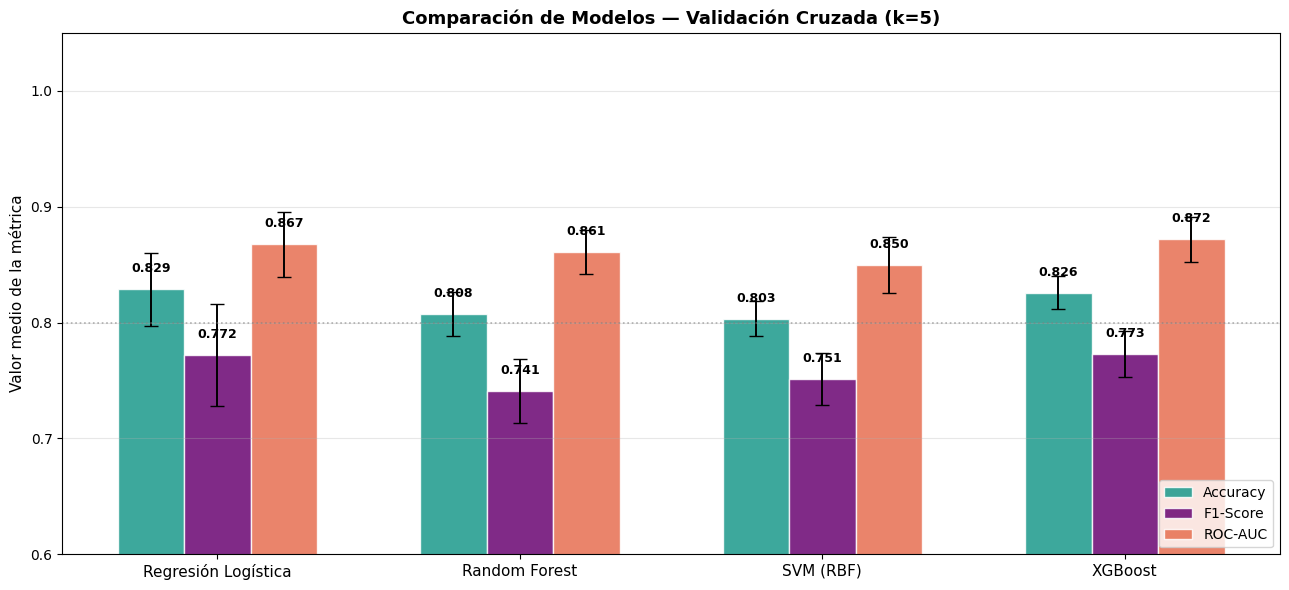

In [ ]:
metricas_cv_plot = ['accuracy', 'f1', 'roc_auc']
labels_cv_plot   = ['Accuracy', 'F1-Score', 'ROC-AUC']
colors_cv        = ['#1B998B', '#6A0572', '#E76F51']

fig, ax_bar = plt.subplots(figsize=(13, 6))

x_pos  = np.arange(len(NOMBRES))
width  = 0.22

for i, (metrica, label, color) in enumerate(
        zip(metricas_cv_plot, labels_cv_plot, colors_cv)):

    medias = [resultados_cv[n][f'test_{metrica}'].mean() for n in NOMBRES]
    stds   = [resultados_cv[n][f'test_{metrica}'].std()  for n in NOMBRES]

    bars = ax_bar.bar(x_pos + width * i, medias, width,
                      label=label, color=color,
                      alpha=0.85, edgecolor='white')


    ax_bar.errorbar(x_pos + width * i, medias, yerr=stds,
                    fmt='none', color='black',
                    capsize=5, linewidth=1.4)

    # etiquetas encima de cada barra
    for bar, v in zip(bars, medias):
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f'{v:.3f}',
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

ax_bar.set_xticks(x_pos + width)
ax_bar.set_xticklabels(NOMBRES, fontsize=11)

ax_bar.set_ylim(0.60, 1.05)
ax_bar.set_ylabel('Valor medio de la métrica', fontsize=11)

ax_bar.set_title(
    'Comparación de Modelos — Validación Cruzada (k=5)',
    fontsize=13, fontweight='bold'
)

ax_bar.legend(fontsize=10, loc='lower right')

ax_bar.grid(axis='y', alpha=0.3)


ax_bar.axhline(y=0.80, linestyle=':', color='gray',
               alpha=0.6, linewidth=1.2)

plt.tight_layout()
plt.show()


### Scores por fold — Análisis de estabilidad


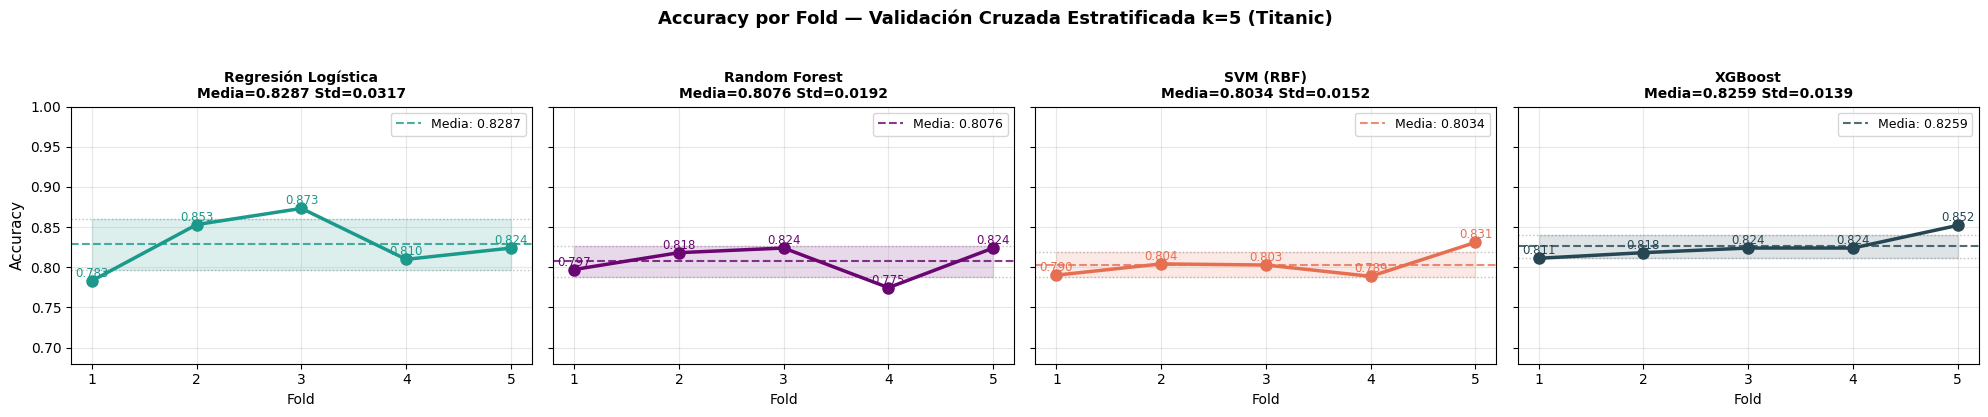

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

for ax, nombre, color in zip(axes, NOMBRES, PALETTE):
    cv_res = resultados_cv[nombre]
    scores = cv_res['test_accuracy']
    folds  = np.arange(1, len(scores) + 1)
    media  = scores.mean()
    std    = scores.std()

    ax.plot(folds, scores, 'o-', color=color, lw=2.5, ms=8, zorder=3)
    ax.fill_between(folds, media - std, media + std, alpha=0.15, color=color)
    ax.axhline(media, linestyle='--', color=color, lw=1.5, alpha=0.8,
               label=f'Media: {media:.4f}')
    ax.axhline(media - std, linestyle=':', color='gray', lw=1, alpha=0.5)
    ax.axhline(media + std, linestyle=':', color='gray', lw=1, alpha=0.5)

    for fold, score in zip(folds, scores):
        ax.text(fold, score + 0.005, f'{score:.3f}',
                ha='center', fontsize=8.5, color=color)

    ax.set_title(f'{nombre}\nMedia={media:.4f} Std={std:.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Fold', fontsize=10)
    ax.set_xticks(folds)
    ax.set_ylim(0.68, 1.0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Accuracy', fontsize=11)
plt.suptitle('Accuracy por Fold — Validación Cruzada Estratificada k=5 (Titanic)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()



### Resumen comparativo: Validación cruzada vs. conjunto de prueba


In [ ]:
nombres_modelos = list(PIPELINES.keys())   # ← corrige el KeyError

print("COMPARATIVA: Accuracy en CV vs. Conjunto de Prueba")
print(f"{'Modelo':<25} {'CV Accuracy':>12} {'Test Accuracy':>14} {'Diferencia':>12}")
print("-" * 65)

for nombre in nombres_modelos:
    cv_acc   = resultados_cv[nombre]['test_accuracy'].mean()
    test_acc = resultados_test[nombre]['Accuracy']
    diff     = test_acc - cv_acc
    print(f"{nombre:<25} {cv_acc:>12.4f} {test_acc:>14.4f} {diff:>+12.4f}")

print("=" * 65)
print("\nUna diferencia pequeña entre CV y Test confirma que no hay")
print("sobreajuste ni fuga de datos.")


COMPARATIVA: Accuracy en CV vs. Conjunto de Prueba
Modelo                     CV Accuracy  Test Accuracy   Diferencia
-----------------------------------------------------------------
Regresión Logística             0.8287         0.8268      -0.0019
Random Forest                   0.8076         0.8324      +0.0248
SVM (RBF)                       0.8034         0.8156      +0.0123
XGBoost                         0.8259         0.8324      +0.0065

Una diferencia pequeña entre CV y Test confirma que no hay
sobreajuste ni fuga de datos.


---

##  SELECCIÓN DEL MEJOR MODELO


In [ ]:
nombres_modelos = list(PIPELINES.keys())   # ← asegura consistencia

resumen_final = []

for nombre in nombres_modelos:
    cv_acc = resultados_cv[nombre]['test_accuracy'].mean()
    cv_std = resultados_cv[nombre]['test_accuracy'].std()
    cv_f1  = resultados_cv[nombre]['test_f1'].mean()
    cv_auc = resultados_cv[nombre]['test_roc_auc'].mean()
    test_acc = resultados_test[nombre]['Accuracy']
    test_f1  = resultados_test[nombre]['F1']        # ← era 'F1-Score', la clave correcta es 'F1'
    test_auc = resultados_test[nombre]['ROC-AUC']

    resumen_final.append({
        'Modelo':        nombre,
        'CV Accuracy':   f"{cv_acc:.4f} ± {cv_std:.4f}",
        'CV F1-Score':   round(cv_f1,  4),
        'CV ROC-AUC':    round(cv_auc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Test F1-Score': round(test_f1,  4),
        'Test ROC-AUC':  round(test_auc, 4)
    })

resumen_df = pd.DataFrame(resumen_final)
print("TABLA RESUMEN — Todos los pipelines")
print(resumen_df.to_string(index=False))

mejor_nombre = max(resultados_test.keys(),
                   key=lambda n: resultados_test[n]['ROC-AUC'])

print(f"\n{'='*50}")
print(f"  MEJOR MODELO  : {mejor_nombre}")
print(f"  ROC-AUC (test): {resultados_test[mejor_nombre]['ROC-AUC']:.4f}")
print(f"  Accuracy (test): {resultados_test[mejor_nombre]['Accuracy']:.4f}")
print(f"  F1-Score (test): {resultados_test[mejor_nombre]['F1']:.4f}")   # ← 'F1', no 'F1-Score'
print(f"{'='*50}")

TABLA RESUMEN — Todos los pipelines
             Modelo     CV Accuracy  CV F1-Score  CV ROC-AUC  Test Accuracy  Test F1-Score  Test ROC-AUC
Regresión Logística 0.8287 ± 0.0317       0.7721      0.8675         0.8268         0.7669        0.8489
      Random Forest 0.8076 ± 0.0192       0.7406      0.8607         0.8324         0.7761        0.8715
          SVM (RBF) 0.8034 ± 0.0152       0.7515      0.8497         0.8156         0.7591        0.8476
            XGBoost 0.8259 ± 0.0139       0.7728      0.8718         0.8324         0.7761        0.8594

  MEJOR MODELO  : Random Forest
  ROC-AUC (test): 0.8715
  Accuracy (test): 0.8324
  F1-Score (test): 0.7761




##  CONCLUSIONES



1. **El desempeño global de los cuatro modelos fue bueno y bastante competitivo**.
Todos los modelos se movieron en un rango relativamente alto de desempeño, con accuracy entre 0.8156 y 0.8324, F1 entre 0.7591 y 0.7761 y ROC-AUC entre 0.8476 y 0.8715 en el conjunto de prueba. Esto indica que el problema de clasificación fue abordado de manera adecuada por el pipeline y que los predictores utilizados sí contienen señal útil para discriminar entre supervivencia y no supervivencia.

2. **Random Forest fue el mejor modelo en el conjunto de prueba**.
En el holdout final, Random Forest alcanzó el mejor ROC-AUC (0.8715) y además empató el mejor accuracy (0.8324), la mejor precision (0.8000), el mejor recall entre los líderes (0.7536), el mejor F1 (0.7761) y la mejor balanced accuracy (0.8177). Desde una perspectiva estrictamente orientada al rendimiento final sobre datos no vistos, fue el modelo más fuerte del ejercicio.

3. **XGBoost fue el modelo más sólido en validación cruzada, aunque no fue el mejor en el test final**.
En validación cruzada estratificada, XGBoost obtuvo el mejor ROC-AUC medio (0.8718) y el mejor F1 medio (0.7728), además de una accuracy media alta (0.8259). Esto sugiere que, en términos de comportamiento promedio sobre múltiples particiones, XGBoost mostró una gran robustez. Sin embargo, en el conjunto de prueba quedó por debajo de Random Forest en ROC-AUC, lo que evidencia que el modelo “ganador” depende del criterio de evaluación que se priorice.

4. **La regresión logística fue una línea base muy fuerte y sorprendentemente competitiva.**
Aunque suele considerarse más simple que Random Forest o XGBoost, la Regresión Logística logró accuracy de 0.8268 en test y 0.8287 ± 0.0317 en validación cruzada, con ROC-AUC de 0.8489 en test y 0.8675 en CV. Esto demuestra que, para este problema, un modelo interpretable y menos complejo puede ofrecer resultados muy cercanos a modelos más sofisticados.

5. **SVM mostró una orientación más favorable hacia la sensibilidad en validación cruzada**.
El modelo SVM (RBF) registró el mayor recall medio en CV (0.7766), lo cual indica que fue el más efectivo para identificar la clase positiva de manera consistente en los folds. Sin embargo, esa ganancia vino acompañada de menor precision media (0.7291) y menor accuracy media (0.8034), lo que refleja un trade-off clásico: recuperar más positivos, pero con un costo mayor en errores de clasificación.

6. **No hubo evidencia fuerte de sobreajuste, y la generalización fue razonablemente estable**.
Las diferencias entre la accuracy promedio de validación cruzada y la accuracy en test fueron pequeñas:

- Regresión Logística: -0.0019

- Random Forest: +0.0248

- SVM: +0.0123

- XGBoost: +0.0065

Esto sugiere una buena capacidad de generalización. Ahora bien, metodológicamente conviene ser prudente: esas diferencias pequeñas son un indicio favorable, aunque por sí solas no prueban de forma absoluta la inexistencia de sobreajuste o fuga. Aun así, el comportamiento observado fue sano y coherente.

7. **El problema presentaba desbalance moderado, y el enfoque metodológico respondió correctamente a esa condición**.
La variable objetivo estaba distribuida aproximadamente en 61.6 % no sobrevivió y 38.4 % sobrevivió. En consecuencia, fue correcto no evaluar únicamente con accuracy. El uso de precision, recall, F1, ROC-AUC y balanced accuracy, junto con partición estratificada, class_weight='balanced' en algunos modelos y scale_pos_weight en XGBoost, fortaleció la validez del ejercicio y evitó conclusiones engañosas.

8. **El pipeline estuvo bien diseñado para prevenir fuga de información y manejar adecuadamente los datos faltantes**.
El notebook eliminó explícitamente la variable alive, que era una representación textual de la variable objetivo y habría provocado data leakage. Además, el preprocesamiento quedó integrado dentro del pipeline, incluyendo imputación de media para numéricas, imputación de moda para categóricas, escalado y OneHotEncoding. Esto fue especialmente importante porque existían faltantes relevantes, por ejemplo en age y sobre todo en deck. En términos metodológicos, este fue uno de los puntos más sólidos del trabajo.

9. **La mejora entre modelos fue real, pero no abismal; por eso la elección final también debe considerar interpretabilidad y costo computacional**.
Aunque Random Forest y XGBoost encabezaron la comparación, la ventaja frente a Regresión Logística no fue enorme. Además, los tiempos de entrenamiento fueron bajos en todos los casos, pero los modelos complejos tardaron más:

- Regresión Logística: 0.52 s

- SVM: 0.45 s

- Random Forest: 1.46 s

- XGBoost: 2.37 s

En un contexto real, esto sugiere que la decisión del modelo no debería basarse solo en décimas de métrica, sino también en interpretabilidad, facilidad de explicación y eficiencia.

10. **La conclusión más importante es que no existe un único “mejor modelo” universal; la selección depende del objetivo analítico**.
Si el objetivo es maximizar el rendimiento final en el conjunto de prueba, Random Forest es la mejor elección.
Si se prioriza robustez promedio en validación cruzada, XGBoost aparece como un candidato muy fuerte.
Si se necesita un modelo más interpretable y con gran competitividad, Regresión Logística resulta altamente defendible.
Y si el foco está en capturar más positivos, SVM merece atención por su recall medio en CV.